In [1]:
from lib import epl 
from lib import OSN
from lib import readout
from lib import plots
import time
import numpy as np
import pickle 
import brian2 as b2
import brian2hears as b2h
import matplotlib.pyplot as plt
#import csv
import os.path
from os import path
from numpy.matlib import repmat
%matplotlib inline
from preprocess import preprocessing as pre

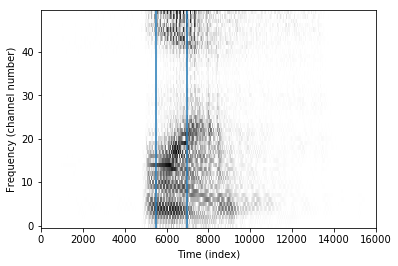

In [2]:
testSounds = ["0a196374_nohash_1","0a2b400e_nohash_0","0a2b400e_nohash_1","0a2b400e_nohash_2","0a2b400e_nohash_3","0a9f9af7_nohash_0","0a9f9af7_nohash_1","0a9f9af7_nohash_2","00f0204f_nohash_0","00f0204f_nohash_1"]
trainingSounds = ["0a196374_nohash_1"]
cfN = 50
scale = 15  #changed because we're normalising in a different way
#I changed scale from 15 to 10 because 16 resulted in a KeyError: 21
# normalising 0 to 1, then multiply by scale (15)
# this is to scale each individual sample

trainingSpect = pre.spectArray(trainingSounds[0], cfN=cfN)

#pre.spectShow(trainingSpect[:,5000:7000]) #, zoom_x=5000, zoom_y=7000)
pre.spectShow(trainingSpect)
trainingIndex = [5500,7000] #changed from 6000 to 7000
range_f = 100
step_f = 10
#range in times of frequencies
#in this notebook, hand select frequencies
lenTraining = len(trainingSounds) * len(trainingIndex)
lenTest = len(testSounds)

#start at 5000 in steps of 50 to 6000
# put in separate jupyter notebook
pre.spectShow(trainingSpect)
plt.axvline(x=trainingIndex[0])
plt.axvline(x=trainingIndex[1])

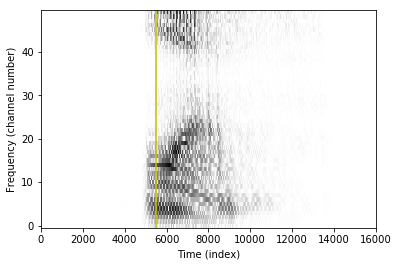

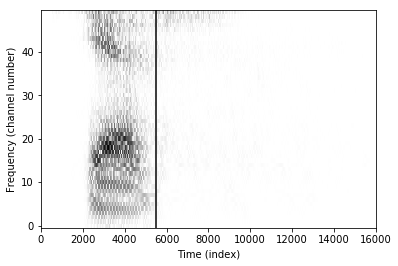

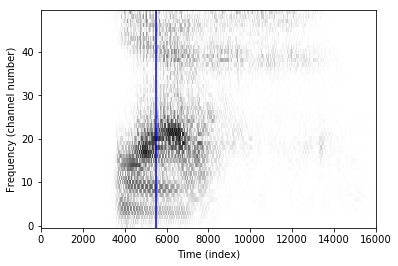

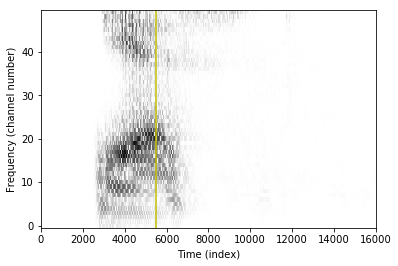

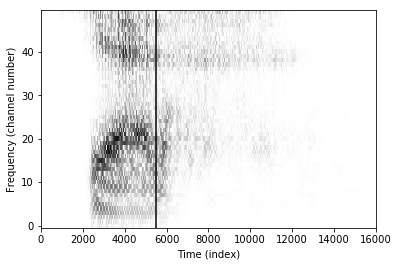

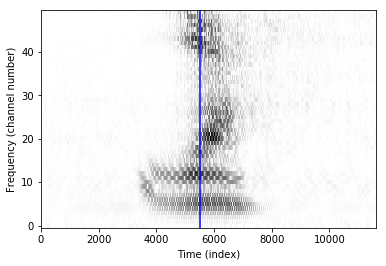

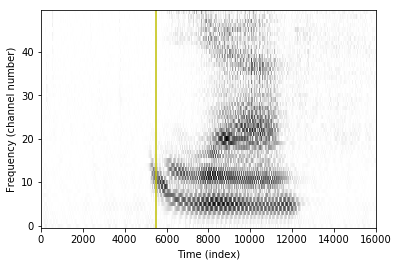

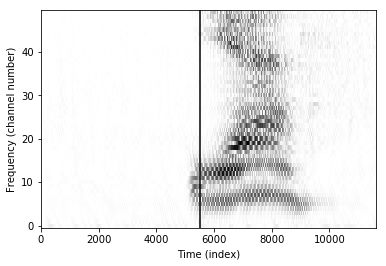

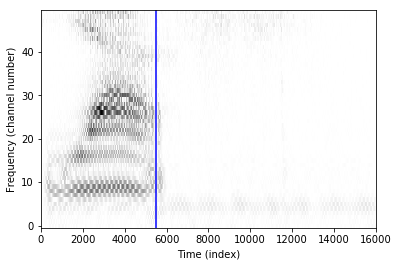

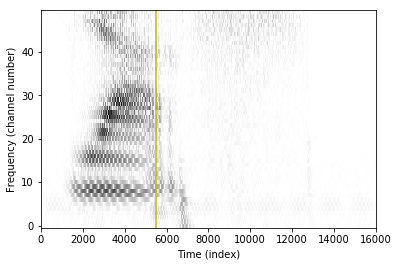

In [3]:
colors = ['y','k','b','y','k','b','y','k','b','y']
#testingIndex = [6000, 3000, 4500, 3900, 3900, 5500, 8500, 6200, 2500, 3000]
testingIndex = [trainingIndex[0]] *10
for sound in trainingSounds: 
    for i in trainingIndex:
        if i == trainingIndex[0]:
            trainingAudio = pre.chooseSound(pre.spectArray(sound, cfN=cfN), range_f, step_f, i, scale);
        else:
            trainingAudio = np.concatenate((trainingAudio, pre.chooseSound(pre.spectArray(sound,cfN=cfN), range_f, step_f, i, scale)))

testAudio = np.array([])

indices_list = []
for sound in testSounds:
    testingSpect = pre.spectArray(sound, cfN=cfN)
    pre.spectShow(testingSpect)

    plt.axvline(x=testingIndex[testSounds.index(sound)], c=colors[testSounds.index(sound)])
    plt.show()
    if testAudio.shape[0] == 0:
        testAudio = pre.chooseSound(testingSpect, range_f, step_f, trainingIndex[0],scale)
    else:
        testAudio = np.concatenate((testAudio,pre.chooseSound(testingSpect, range_f, step_f, trainingIndex[0],scale)))


In [ ]:
from lib import epl
nGammaPerTraining = 10
nGammaPerOdor = 10  #for this dataset nGammaPerOdor = 5 is not enough for differentiation as shown in SImatrix
print("Number of odors to train = " + str(lenTraining)); 
print("Number of odors to test = " + str(lenTest)); 

#Network initialization
nMCs = len(trainingAudio[0]); 
GCsPerNeurogenesis = 5; 
nGCs = nMCs*GCsPerNeurogenesis*lenTraining;     #every MC has 5 GCs per odor  
epl = epl.EPL(nMCs, nGCs, GCsPerNeurogenesis); 

#Sniff
def sniff(odor, learn_flag=0, nGammaPerOdor=5, gPeriod=40):
    sensorInput = OSN.OSN_encoding(odor); 
    for j in range(0, nGammaPerOdor):
        for k in range(0, gPeriod): 
            epl.update(sensorInput, learn_flag=learn_flag);
            pass; 
    epl.reset(); 

#Training
t1 = time.time(); 
for i in range(0, lenTraining):
    print("Training odor " + str(i+1)) 
    sniff(trainingAudio[i], learn_flag=1,nGammaPerOdor = nGammaPerTraining); 
    # changed nGammaPerOdor from 5 to 10
    epl.GClayer.invokeNeurogenesis();
#added this for loop to change structure of epl.gammaCode
for i in range(0, lenTraining):
    sniff(trainingAudio[i], learn_flag=0, nGammaPerOdor = nGammaPerOdor); #try nGammaPerTraining
    
#Testing
for i in range(0, lenTest):
    sniff(testAudio[i], learn_flag=0, nGammaPerOdor = nGammaPerOdor); 
    if((i+1)%10==0):
        print(str(i+1) + " odors tested"); 
t2 = time.time(); 
print("Simulation Duration = " + str(t2-t1) + "s")


Number of odors to train = 2
Number of odors to test = 10
Training odor 1


## epl gammaCode parsing

if I keep nGammaPerTraining in the second training loop, I need to change it in epl gammaCode parsing as well

In [6]:
#Remember the first training loop uses nGammaPerOdor = 10

gammaCode_size = lenTraining*(nGammaPerTraining + nGammaPerTraining) + lenTest * nGammaPerOdor
(gammaCode_size,len(epl.gammaCode))

(140, 140)

In [7]:
trained = np.array(epl.gammaCode[lenTraining*nGammaPerTraining:lenTraining*(nGammaPerTraining+nGammaPerOdor)]).reshape(nGammaPerOdor, lenTraining,-1)#/nGammaPerOdor, -1)
#put lenTest/nGammaPerOdor into another variable
tested = np.array(epl.gammaCode[lenTraining*(nGammaPerTraining+nGammaPerOdor):]).reshape(nGammaPerOdor, lenTest, -1)

In [8]:

true_negative = 0
false_positive = 0


SImatrix = np.zeros((lenTraining, lenTest), dtype =float)  
for i in range(0, len(trained[-1])):
    for j in range(0, len(tested[-1])):
        SImatrix[i][j] = (pre.computeSimilarity(trained[-1][i], tested[-1][j]))
decisionMatrix = (SImatrix> 0.75)

In [9]:
#designing truth Table
truthTable = np.tile([True, False], (lenTest,1)).T

In [10]:
truthTable

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [False, False, False, False, False, False, False, False, False,
        False]])

In [11]:
decisionMatrix

array([[False, False, False, False, False, False, False, False, False,
        False],
       [False, False, False, False, False, False, False, False, False,
        False]])

In [12]:
SImatrix

array([[0.0718, 0.087 , 0.0893, 0.0965, 0.1038, 0.1013, 0.1013, 0.1013,
        0.1013, 0.1013],
       [0.0718, 0.087 , 0.0893, 0.0965, 0.1038, 0.1013, 0.1013, 0.1013,
        0.1013, 0.1013]])

In [13]:
for l in (decisionMatrix==truthTable):
    true_negative += sum((decisionMatrix==truthTable).reshape((1,20)))

In [14]:
sum((decisionMatrix==truthTable).reshape((1,20)))

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [15]:
decisionMatrix==truthTable

array([[False, False, False, False, False, False, False, False, False,
        False],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True]])

In [16]:
pre.results(decisionMatrix, truthTable)

(10, 10)

Text(0.5,0,'Time (index)')

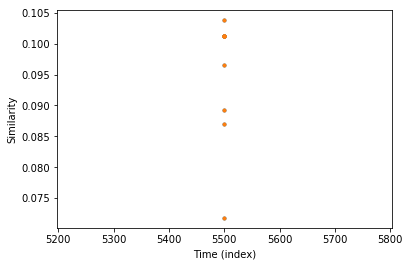

In [17]:
plt.plot([trainingIndex[0]]*lenTest , SImatrix.T, ".") 
plt.ylabel('Similarity')
plt.xlabel('Time (index)')
